In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import xarray as xr
import regionmask as regmask
import matplotlib.pyplot as plt
import xclimate as xclim

In [3]:
time_slice = slice("2000-01", "2005-12")
year_start = time_slice.start[:4]
year_end = time_slice.stop[:4]
variables = [
    # "SMP_month_1",
    # "SOILLIQ_month_1",
    # "SOILWATER_10CM_month_1",
    # "BTRANMN_month_1",

    # "SMP_day_1",
    "SOILWATER_10CM_day_1",
    "BTRANMN_day_1",
    "TREFMXAV_day_1",
    "TREFMNAV_day_1",
]

lens_member = "1011.001"
goga_member = "01"

# FHIST

In [26]:
grid = xclim.load_fhist_ppe_grid()

fhist = {}
for v in variables:
    print(v)
    name = "_".join(v.split("_")[:-2])
    fhist[v] = xclim.load_fhist(v, keep_var_only=True)[name].sel(time=time_slice).reindex_like(grid, method="nearest", tolerance=1e-3)
    fhist[v] = fhist[v].where(grid.LANDFRAC > 0).chunk({'time': -1})

SOILWATER_10CM_day_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
BTRANMN_day_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
TREFMXAV_day_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
TREFMNAV_day_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


In [27]:
fhist_soilliq = xclim.load_fhist('SOILLIQ_month_1', keep_var_only=False)
levgrnd = fhist_soilliq.levgrnd
levdcmp = fhist_soilliq.levdcmp

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


# LENS2 and GOGA2

In [28]:
grid_lens = xclim.load_cesm2le_grid()
grid_goga = xclim.load_goga2_grid()

lens = {}
goga = {}
for v in variables:
    print(v)
    name = "_".join(v.split("_")[:-2])
    freq = "_".join(v.split("_")[-2:])

    try:
        lens[v] = (
            xclim.load_cesm2le(name, "lnd", freq, "h5", member=lens_member, experiment="historical", bb="smbb", keep_var_only=True)
            .sel(time=time_slice)[name]
            .reindex_like(grid_lens, method="nearest", tolerance=1e-3)
            .where(grid_lens.LANDFRAC > 0)
            .chunk({'time': -1, 'lat': -1, 'lon': -1})
        )
    except:
        print(f"Could not load LENS2 {v}")

    try:
        goga[v] = (
            xclim.load_goga2(name, "lnd", freq, "h1", member=goga_member, experiment="historical", keep_var_only=True)
            .sel(time=time_slice)[name]
            .reindex_like(grid_goga, method="nearest", tolerance=1e-3)
            .where(grid_goga.LANDFRAC > 0)
            .chunk({'time': -1, 'lat': -1, 'lon': -1})
        )
    except:
        print(f"Could not load GOGA2 {v}")

SOILWATER_10CM_day_1
BTRANMN_day_1
Could not load GOGA2 BTRANMN_day_1
TREFMXAV_day_1
Could not load LENS2 TREFMXAV_day_1
Could not load GOGA2 TREFMXAV_day_1
TREFMNAV_day_1
Could not load LENS2 TREFMNAV_day_1
Could not load GOGA2 TREFMNAV_day_1


In [29]:
lon = grid.lon
lat = grid.lat

cna = regmask.defined_regions.ar6.land.mask(lon, lat) == 4

In [30]:
def select_months(da, months):
    return da.where(da.time.dt.month.isin(months), drop=True)

In [31]:
fhist_cna_jja = {}
lens_cna_jja = {}
goga_cna_jja = {}

jja_months = [6, 7, 8]

for v in variables:
    fhist_cna_jja[v] = select_months(fhist[v].where(cna).weighted(grid.LANDAREA).mean(dim=['lat', 'lon']).compute(), jja_months)
    lens_cna_jja[v] = select_months(lens[v].where(cna).weighted(grid_lens.LANDAREA).mean(dim=['lat', 'lon']).compute(), jja_months)
    try:
        goga_cna_jja[v] = select_months(goga[v].where(cna).weighted(grid_goga.LANDAREA).mean(dim=['lat', 'lon']).compute(), jja_months)
    except KeyError:
        continue

KeyError: 'TREFMXAV_day_1'

In [ ]:
fhist_cna_jja_q = {}
for v in variables:
    fhist_cna_jja_q[v] = fhist_cna_jja[v].quantile(np.linspace(0, 1, 101), dim='time')

In [ ]:
fhist_cna_jja_q.keys()

dict_keys(['SOILWATER_10CM_day_1', 'BTRANMN_day_1'])

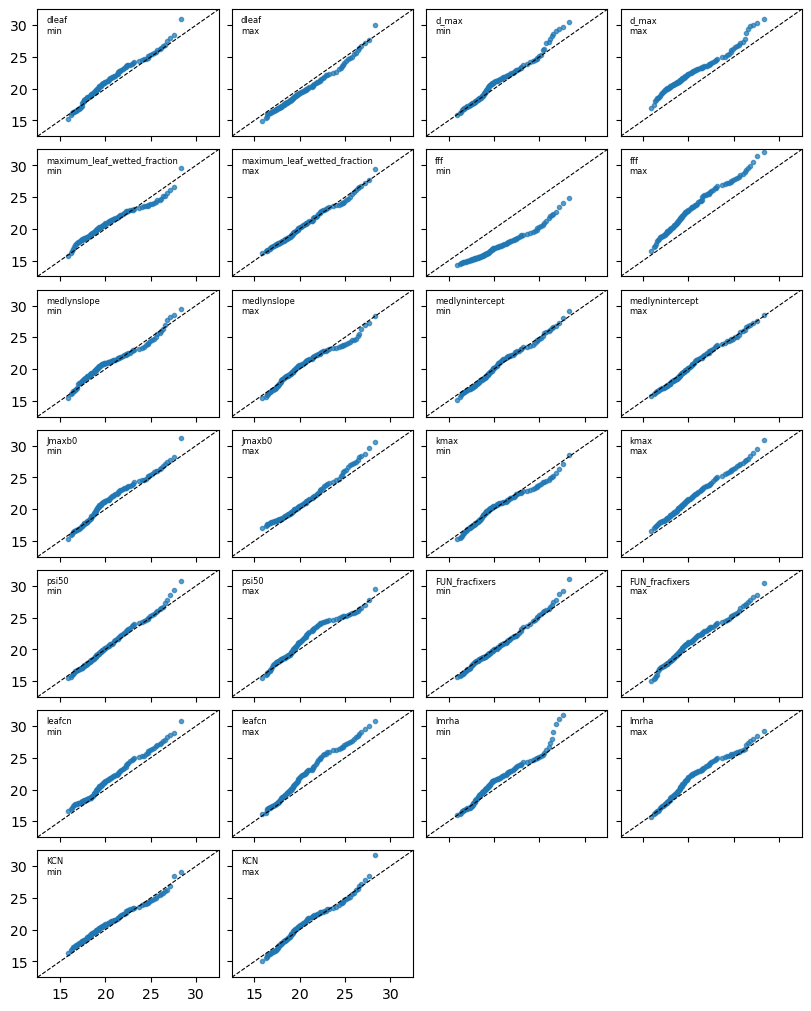

In [ ]:
fig, axes = plt.subplots(7, 4, figsize=(8, 10), sharex=True, sharey=True, layout='constrained')
axs = axes.ravel()

for i in range(0, 26):

    x = fhist_cna_jja_q['SOILWATER_10CM_day_1'].isel(member=0).values
    y = fhist_cna_jja_q['SOILWATER_10CM_day_1'].isel(member=i+1).values

    axs[i].plot(x, y, '.', alpha=0.7)
    vmin = np.nanmin(np.concatenate([np.atleast_1d(abs(x)), np.atleast_1d(abs(y))]))
    vmax = np.nanmax(np.concatenate([np.atleast_1d(abs(x)), np.atleast_1d(abs(y))]))

    vmin = 12.5
    vmax = 32.5

    axs[i].plot([vmin, vmax], [vmin, vmax], '--', color='k', lw=0.8)
    axs[i].set_xlim(vmin, vmax)
    axs[i].set_ylim(vmin, vmax)

    axs[i].text(
        x=0.05,
        y=0.95,
        s=f"{xclim.ppe.get_member_info(i+1)[1]}\n{xclim.ppe.get_member_info(i+1)[2]}",
        fontsize=6,
        transform=axs[i].transAxes,
        va='top'
    )

for i in range(1,3):
    axs[-i].remove()

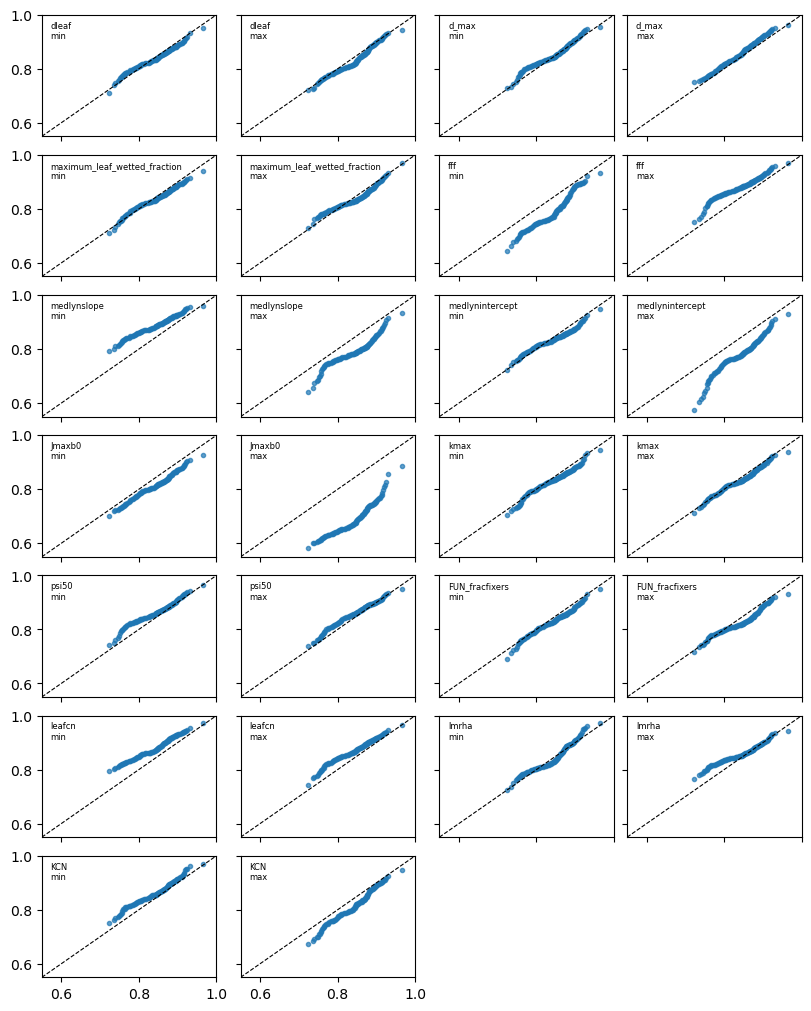

In [ ]:
fig, axes = plt.subplots(7, 4, figsize=(8, 10), sharex=True, sharey=True, layout='constrained')
axs = axes.ravel()

for i in range(0, 26):

    x = fhist_cna_jja_q['BTRANMN_day_1'].isel(member=0).values
    y = fhist_cna_jja_q['BTRANMN_day_1'].isel(member=i+1).values

    axs[i].plot(x, y, '.', alpha=0.7)
    vmin = np.nanmin(np.concatenate([np.atleast_1d(abs(x)), np.atleast_1d(abs(y))]))
    vmax = np.nanmax(np.concatenate([np.atleast_1d(abs(x)), np.atleast_1d(abs(y))]))

    vmin = 0.55
    vmax = 1

    axs[i].plot([vmin, vmax], [vmin, vmax], '--', color='k', lw=0.8)
    axs[i].set_xlim(vmin, vmax)
    axs[i].set_ylim(vmin, vmax)

    axs[i].text(
        x=0.05,
        y=0.95,
        s=f"{xclim.ppe.get_member_info(i+1)[1]}\n{xclim.ppe.get_member_info(i+1)[2]}",
        fontsize=6,
        transform=axs[i].transAxes,
        va='top'
    )

for i in range(1,3):
    axs[-i].remove()

In [ ]:
fig, axes = plt.subplots(7, 4, figsize=(8, 10), sharex=True, sharey=True, layout='constrained')
axs = axes.ravel()

for i in range(0, 26):

    x = fhist_cna_jja_q['TREFMXAV_10CM_day_1'].isel(member=0).values
    y = fhist_cna_jja_q['TREFMXAV_10CM_day_1'].isel(member=i+1).values

    axs[i].plot(x, y, '.', alpha=0.7)
    vmin = np.nanmin(np.concatenate([np.atleast_1d(abs(x)), np.atleast_1d(abs(y))]))
    vmax = np.nanmax(np.concatenate([np.atleast_1d(abs(x)), np.atleast_1d(abs(y))]))

    vmin = 12.5
    vmax = 32.5

    axs[i].plot([vmin, vmax], [vmin, vmax], '--', color='k', lw=0.8)
    axs[i].set_xlim(vmin, vmax)
    axs[i].set_ylim(vmin, vmax)

    axs[i].text(
        x=0.05,
        y=0.95,
        s=f"{xclim.ppe.get_member_info(i+1)[1]}\n{xclim.ppe.get_member_info(i+1)[2]}",
        fontsize=6,
        transform=axs[i].transAxes,
        va='top'
    )

for i in range(1,3):
    axs[-i].remove()

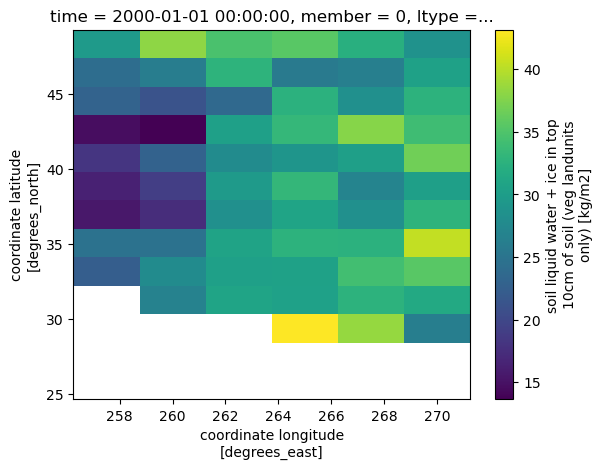

In [ ]:
fhist['SOILWATER_10CM_day_1'].isel(member=0, time=0).where(cna, drop=True).plot()

In [46]:
# fhist_smp = fhist['SMP_month_1'].isel(member=0).sel(levgrnd=slice(0, 9)).mean(dim='levgrnd')
# lens_smp = lens['SMP_month_1'].sel(levgrnd=slice(0, 9)).mean(dim='levgrnd')
# goga_smp = goga['SMP_month_1'].sel(levgrnd=slice(0, 9)).mean(dim='levgrnd')

# fhist_sl_1_0 = fhist['SOILLIQ_month_1'].isel(member=0).sel(levsoi=slice(0, 9)).sum(dim='levsoi')
# lens_sl_1_0 = lens['SOILLIQ_month_1'].sel(levsoi=slice(0, 9)).sum(dim='levsoi')
# goga_sl_1_0 = goga['SOILLIQ_month_1'].sel(levsoi=slice(0, 9)).sum(dim='levsoi')

# fhist_sl_0_10 = fhist['SOILWATER_10CM_month_1'].isel(member=0)
# lens_sl_0_10 = lens['SOILWATER_10CM_month_1']
# goga_sl_0_10 = goga['SOILWATER_10CM_month_1']

In [78]:
gc = {'lat': 45, 'lon': 110, 'method': 'nearest'}

fhist_smp_gc = fhist_smp.sel(**gc).compute()
fhist_sl_1_0_gc = fhist_sl_1_0.sel(**gc).compute()
fhist_sl_0_10_gc = fhist_sl_0_10.sel(**gc).compute()

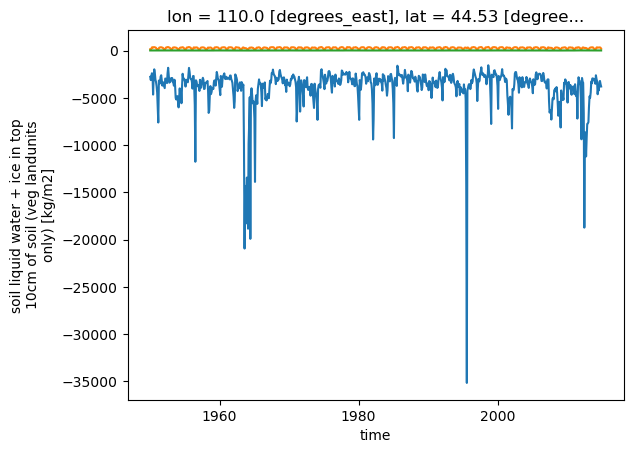

In [83]:
fhist_smp_gc.plot()
fhist_sl_1_0_gc.plot()
fhist_sl_0_10_gc.plot()

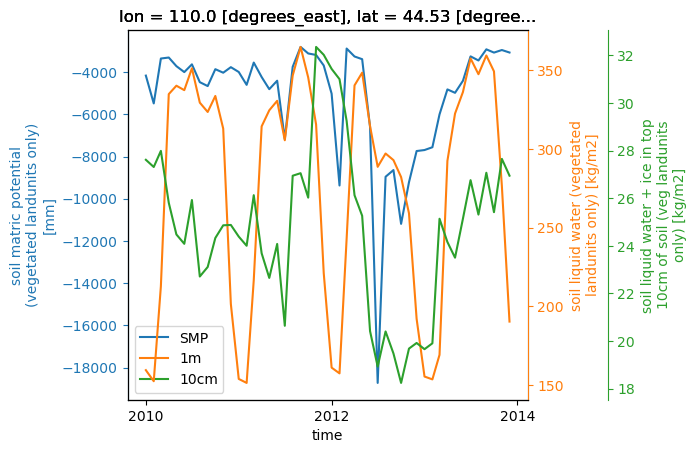

In [86]:
fig, ax = plt.subplots()
fig.subplots_adjust(right=0.75)  # make room for two right axes

ax2 = ax.twinx()
ax3 = ax.twinx()

# Offset ax3 spine to the right
ax3.spines['right'].set_position(('axes', 1.2))

fhist_smp_gc.sel(time=slice('2010-01', '2013-12')).plot(ax=ax, color='tab:blue', label='SMP')
fhist_sl_1_0_gc.sel(time=slice('2010-01', '2013-12')).plot(ax=ax2, color='tab:orange', label='1m')
fhist_sl_0_10_gc.sel(time=slice('2010-01', '2013-12')).plot(ax=ax3, color='tab:green', label='10cm')

ax3.spines['right'].set_visible(True)  # ensure spine is drawn

ax.legend()

handles = (
    ax.get_legend_handles_labels()[0]
    + ax2.get_legend_handles_labels()[0]
    + ax3.get_legend_handles_labels()[0]
)
labels = (
    ax.get_legend_handles_labels()[1]
    + ax2.get_legend_handles_labels()[1]
    + ax3.get_legend_handles_labels()[1]
)

ax.legend(handles, labels)

for axis, color in zip([ax, ax2, ax3], ['tab:blue', 'tab:orange', 'tab:green']):
    axis.spines['right'].set_color(color)
    axis.yaxis.label.set_color(color)
    axis.tick_params(axis='y', colors=color)

ax.spines['left'].set_color('tab:blue')

In [ ]:
fhist_smp.sel(**gc).rolling(time=12, center=True).mean().plot(ax=ax, color='tab:blue', label='SMP')
fhist_sl_1_0.sel(**gc).rolling(time=12, center=True).mean().plot(ax=ax2, color='tab:orange', label='1m')
fhist_sl_0_10.sel(**gc).rolling(time=12, center=True).mean().plot(ax=ax3, color='tab:green', label='10cm')

In [79]:
fhist_smp_gc_nan = fhist_smp_gc[~np.isnan(fhist_smp_gc)]
fhist_sl_1_0_gc_nan = fhist_sl_1_0_gc[~np.isnan(fhist_sl_1_0_gc)]
fhist_sl_0_10_gc_nan = fhist_sl_0_10_gc[~np.isnan(fhist_sl_0_10_gc)]

In [80]:
np.corrcoef(fhist_smp_gc_nan, fhist_sl_1_0_gc_nan)

array([[1.        , 0.22155208],
       [0.22155208, 1.        ]])

In [81]:
np.corrcoef(fhist_smp_gc_nan, fhist_sl_0_10_gc_nan)

array([[1.        , 0.67164009],
       [0.67164009, 1.        ]])

In [82]:
np.corrcoef(fhist_sl_1_0_gc_nan, fhist_sl_0_10_gc_nan)

array([[1.        , 0.00571159],
       [0.00571159, 1.        ]])